# Full-Trace Per-Prompt Statistical Analysis

A companion to `70b_blocks_analysis.ipynb`, using full-trace **per-prompt features** for Emotional, Neutral, and Joyful. The existing whole-trace notebook remains separate.

For each condition pair: single-feature k=2 clustering and ARI, trace-level Welch/Mann–Whitney tests with Bonferroni correction, random-label null checks, and balanced prompt-subset robustness sweeps.

Prompt clustering is descriptive: samples from one recording are dependent. Inferential tests use one mean per trace, not 20 independent prompt observations. Different traces may still share hardware, prompts, or acquisition batches; these tests do not control those dependencies or establish a causal condition effect. A block-style within-run majority filter does not apply because each full trace contains only one condition.

Run all cells from the repository or notebook directory. Inputs are `data/fulltrace_prompts/*_prompts.csv` and `data/fulltrace/*_prompts.csv`; aggregate files are excluded. No source CSVs are modified. `joy` is displayed as `joyful`; filenames do not override recorded labels.

In [1]:
from pathlib import Path
from itertools import combinations
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'fulltrace').is_dir())
DATA_DIRS = [BASE_DIR / 'data' / 'fulltrace', BASE_DIR / 'data' / 'fulltrace_prompts']
CONDITIONS = ['emotional', 'neutral', 'joyful']
CODES = {'emotional': 'E', 'neutral': 'N', 'joyful': 'J'}
COLORS = {'emotional': '#333333', 'neutral': '#999999', 'joyful': '#d98c00'}
FEATURES = [f'core_power.throttle__{m}' for m in ['mean_rate', 'variance', 'spectral_entropy', 'slope']]
SEED = 42
N_INIT = 50
N_NULL_REPEATS = 20
N_REPEATS = 20
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]

## 1 — Load and validate per-prompt features

In [2]:
frames = []
for directory in DATA_DIRS:
    for path in sorted(directory.glob('*_prompts.csv')):
        if path.name == 'all_prompts.csv':
            continue
        frame = pd.read_csv(path)
        if not {'run_label', 'condition', 'prompt_index', 'mode'}.issubset(frame):
            raise ValueError(f'Invalid prompt feature CSV: {path}')
        if not frame['mode'].eq('per_prompt').all():
            raise ValueError(f'Expected per-prompt features: {path}')
        frame['source_csv'] = str(path.relative_to(BASE_DIR))
        frames.append(frame)
if not frames:
    raise ValueError('No per-prompt feature CSVs found. Run extract_features_fulltrace.py first.')
df_all = pd.concat(frames, ignore_index=True)
df_all['condition'] = df_all.condition.replace({'joy': 'joyful', 'independentJ': 'joyful'})
keys = ['run_label', 'prompt_index']
# Identical copies are safe to deduplicate; conflicting copies require review.
compare_cols = ['condition'] + [f for f in FEATURES if f in df_all]
conflicts = df_all.groupby(keys)[compare_cols].nunique(dropna=False).gt(1).any(axis=1)
if conflicts.any():
    raise ValueError(f'Conflicting duplicate prompts: {conflicts[conflicts].index.tolist()}')
df_all = df_all.drop_duplicates(keys).reset_index(drop=True)
if not df_all.condition.isin(CONDITIONS).all():
    raise ValueError('Unexpected condition labels.')
if df_all.groupby('run_label').condition.nunique().gt(1).any():
    raise ValueError('A trace has multiple condition labels.')
label_issues = []
for run, group in df_all.groupby('run_label'):
    match = re.search(r'_([EJN])_\d+$', run)
    if match and match.group(1) != CODES[group.condition.iloc[0]]:
        label_issues.append({'run': run, 'filename_code': match.group(1), 'recorded_condition': group.condition.iloc[0]})
if label_issues:
    print('LABEL MISMATCHES — recorded labels retained; review source metadata:')
    print(pd.DataFrame(label_issues).to_string(index=False))
print(df_all.groupby('condition').agg(prompts=('prompt_index', 'size'), traces=('run_label', 'nunique')))
PAIRS = list(combinations([c for c in CONDITIONS if (df_all.condition == c).any()], 2))
if len(PAIRS) != 3:
    raise ValueError('All three conditions are required for this notebook.')
missing = set(FEATURES) - set(df_all)
if missing:
    raise ValueError(f'Missing features: {missing}')
df_all[FEATURES] = df_all[FEATURES].replace([np.inf, -np.inf], np.nan)
trace_means = df_all.groupby(['run_label', 'condition'])[FEATURES].mean().reset_index()
print('Missing feature values:', df_all[FEATURES].isna().sum().to_dict())

LABEL MISMATCHES — recorded labels retained; review source metadata:
    run filename_code recorded_condition
229_N_1             N             joyful
234_N_1             N             joyful
248_N_1             N             joyful
251_N_1             N             joyful
           prompts  traces
condition                 
emotional      400      20
joyful         320      16
neutral        400      20
Missing feature values: {'core_power.throttle__mean_rate': 0, 'core_power.throttle__variance': 0, 'core_power.throttle__spectral_entropy': 0, 'core_power.throttle__slope': 0}


## 2 — Single-feature clustering and trace-level statistical tests

Clustering uses complete prompt observations for each feature and condition pair. Tests and Cohen’s d use trace means. Bonferroni correction covers all feature/pair comparisons separately for each test family. No imputation is used.

In [3]:
def kmeans_acc_ari(X, y):
    Xs = StandardScaler().fit_transform(X)
    pred = KMeans(n_clusters=2, n_init=N_INIT, random_state=SEED).fit_predict(Xs)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    acc = max(cm[0, 0] + cm[1, 1], cm[0, 1] + cm[1, 0]) / cm.sum()
    return acc, adjusted_rand_score(y, pred)

records = []
for left, right in PAIRS:
    for feature in FEATURES:
        sub = df_all.loc[df_all.condition.isin([left, right]), ['condition', feature]].dropna()
        acc, ari = kmeans_acc_ari(sub[[feature]], (sub.condition == left).astype(int))
        a = trace_means.loc[trace_means.condition == left, feature].dropna()
        b = trace_means.loc[trace_means.condition == right, feature].dropna()
        if min(len(a), len(b)) < 2:
            raise ValueError(f'Need at least two traces per condition: {left}/{right}, {feature}')
        t, tp = ttest_ind(a, b, equal_var=False)
        u, up = mannwhitneyu(a, b, alternative='two-sided')
        sd = np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
        records.append(dict(pair=f'{CODES[left]}–{CODES[right]}', left=left, right=right,
                            feature=feature, accuracy=acc, ari=ari,
                            n_left_traces=len(a), n_right_traces=len(b),
                            left_mean=a.mean(), right_mean=b.mean(),
                            direction='↑'+CODES[left if a.mean() > b.mean() else right],
                            cohens_d=abs(a.mean()-b.mean())/sd if sd > 0 else np.nan,
                            t=t, t_p=tp, U=u, mwu_p=up))
stats = pd.DataFrame(records)
stats['t_p_corr'] = (stats.t_p * len(stats)).clip(upper=1)
stats['mwu_p_corr'] = (stats.mwu_p * len(stats)).clip(upper=1)
print(stats.to_string(index=False))

pair      left   right                               feature  accuracy       ari  n_left_traces  n_right_traces    left_mean   right_mean direction  cohens_d         t          t_p     U    mwu_p     t_p_corr  mwu_p_corr
 E–N emotional neutral        core_power.throttle__mean_rate  0.638750  0.075899             20              20 2.472551e+05 2.343614e+05        ↑E  1.051946  3.326546 2.150941e-03 316.0 0.001782 2.581129e-02    0.021389
 E–N emotional neutral         core_power.throttle__variance  0.536250  0.004288             20              20 3.694693e+13 3.595632e+13        ↑E  0.115343  0.364747 7.173224e-01 210.0 0.797197 1.000000e+00    1.000000
 E–N emotional neutral core_power.throttle__spectral_entropy  0.540000  0.005783             20              20 9.020166e-01 8.937180e-01        ↑E  0.491888  1.555485 1.286800e-01 251.0 0.171930 1.000000e+00    1.000000
 E–N emotional neutral            core_power.throttle__slope  0.566250  0.016325             20              20 5.55

## 3 — Feature distributions

Each point is a trace’s mean per-prompt feature, not a feature computed on the entire concatenated signal.

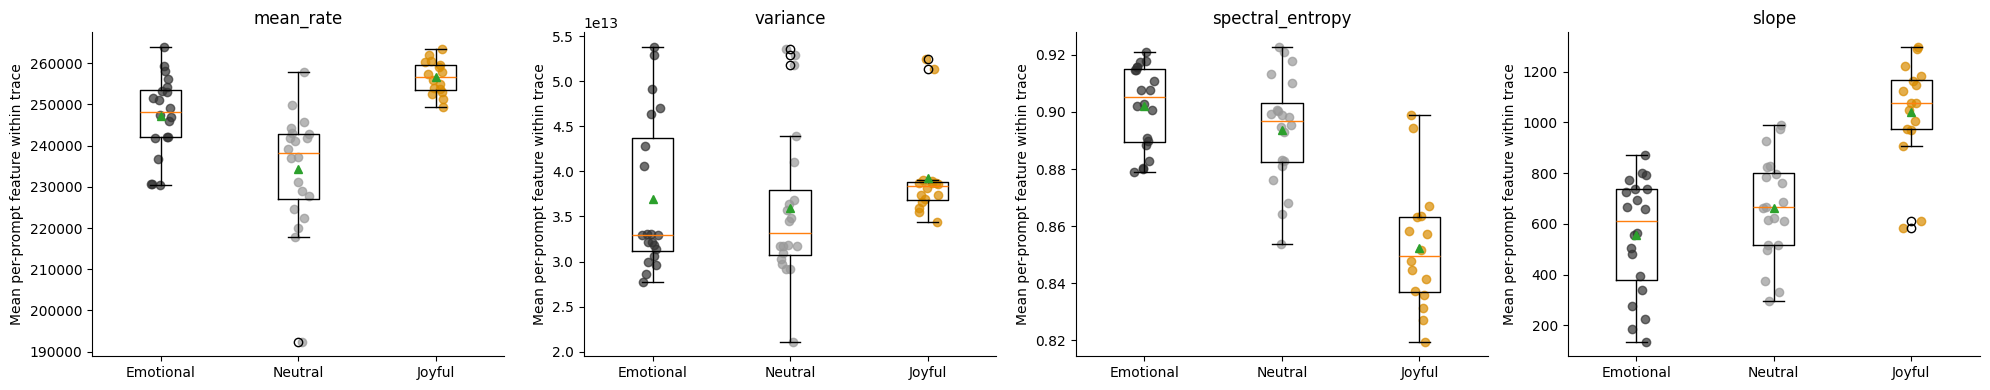

In [4]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(5*len(FEATURES), 4), squeeze=False)
rng = np.random.default_rng(SEED)
for ax, feature in zip(axes[0], FEATURES):
    groups = [trace_means.loc[trace_means.condition == c, feature].dropna().values for c in CONDITIONS]
    ax.boxplot(groups, positions=range(3), showmeans=True)
    for i, (cond, vals) in enumerate(zip(CONDITIONS, groups)):
        ax.scatter(i+rng.uniform(-0.08, 0.08, len(vals)), vals, color=COLORS[cond], alpha=0.7)
    ax.set_xticks(range(3), [c.title() for c in CONDITIONS])
    ax.set_title(feature.split('__')[-1])
    ax.set_ylabel('Mean per-prompt feature within trace')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4 — Random-label null check

As in the blocks notebook, split one condition into balanced random binary pseudo-labels and repeat clustering. Here pseudo-labels are assigned to entire traces and inherited by their prompts to preserve within-trace dependence. The 50% line is a reference, not a calibrated significance threshold; label alignment and unequal trace sizes can raise accuracy.

In [5]:
null_rows = []
rng = np.random.default_rng(SEED)
for cond in CONDITIONS:
    for feature in FEATURES:
        sub = df_all.loc[df_all.condition == cond, ['run_label', feature]].dropna()
        runs = sub.run_label.unique()
        if len(runs) < 2:
            continue
        for repeat in range(N_NULL_REPEATS):
            pseudo = np.zeros(len(runs), dtype=int)
            pseudo[:len(runs)//2] = 1
            rng.shuffle(pseudo)
            y = sub.run_label.map(dict(zip(runs, pseudo)))
            acc, ari = kmeans_acc_ari(sub[[feature]], y)
            null_rows.append(dict(condition=cond, feature=feature, repeat=repeat, accuracy=acc, ari=ari))
null_results = pd.DataFrame(null_rows)
print(null_results.groupby(['condition', 'feature'])[['accuracy', 'ari']].agg(['mean', 'std']).to_string())

                                                 accuracy                 ari          
                                                     mean       std      mean       std
condition feature                                                                      
emotional core_power.throttle__mean_rate         0.556500  0.034607  0.015247  0.020022
          core_power.throttle__slope             0.533500  0.036004  0.006931  0.021963
          core_power.throttle__spectral_entropy  0.512500  0.009665  0.000078  0.001281
          core_power.throttle__variance          0.556750  0.035477  0.015593  0.020565
joyful    core_power.throttle__mean_rate         0.530625  0.029864  0.004031  0.014469
          core_power.throttle__slope             0.561250  0.044914  0.019772  0.030384
          core_power.throttle__spectral_entropy  0.541875  0.030322  0.007643  0.014236
          core_power.throttle__variance          0.521250  0.043604  0.007850  0.018554
neutral   core_power.throttle__m

## 5 — Balanced prompt-subset robustness sweep

For each condition pair’s best descriptive clustering feature, select x/2 prompt indices per condition, pool those prompts across traces, and repeat 20 times. Selecting equal numbers of indices does not balance trial counts when conditions have different numbers of traces. This is a sensitivity check, not held-out predictive accuracy.

pair                               feature  x  mean_acc  std_acc  mean_ari  total
 E–J core_power.throttle__spectral_entropy 22  0.809217 0.044450  0.387881  396.0
 E–J core_power.throttle__spectral_entropy 24  0.799421 0.035172  0.361268  432.0
 E–J core_power.throttle__spectral_entropy 26  0.802350 0.035045  0.368447  468.0
 E–J core_power.throttle__spectral_entropy 28  0.808532 0.021003  0.380712  504.0
 E–J core_power.throttle__spectral_entropy 30  0.806111 0.024026  0.375258  540.0
 E–J core_power.throttle__spectral_entropy 32  0.811979 0.020184  0.389331  576.0
 E–J core_power.throttle__spectral_entropy 34  0.812418 0.018904  0.390271  612.0
 E–J core_power.throttle__spectral_entropy 36  0.803627 0.011183  0.367728  648.0
 E–J core_power.throttle__spectral_entropy 38  0.802266 0.005941  0.364136  684.0
 E–J core_power.throttle__spectral_entropy 40  0.804167 0.000000  0.368657  720.0
 E–N        core_power.throttle__mean_rate 22  0.642500 0.070329  0.098242  440.0
 E–N        core

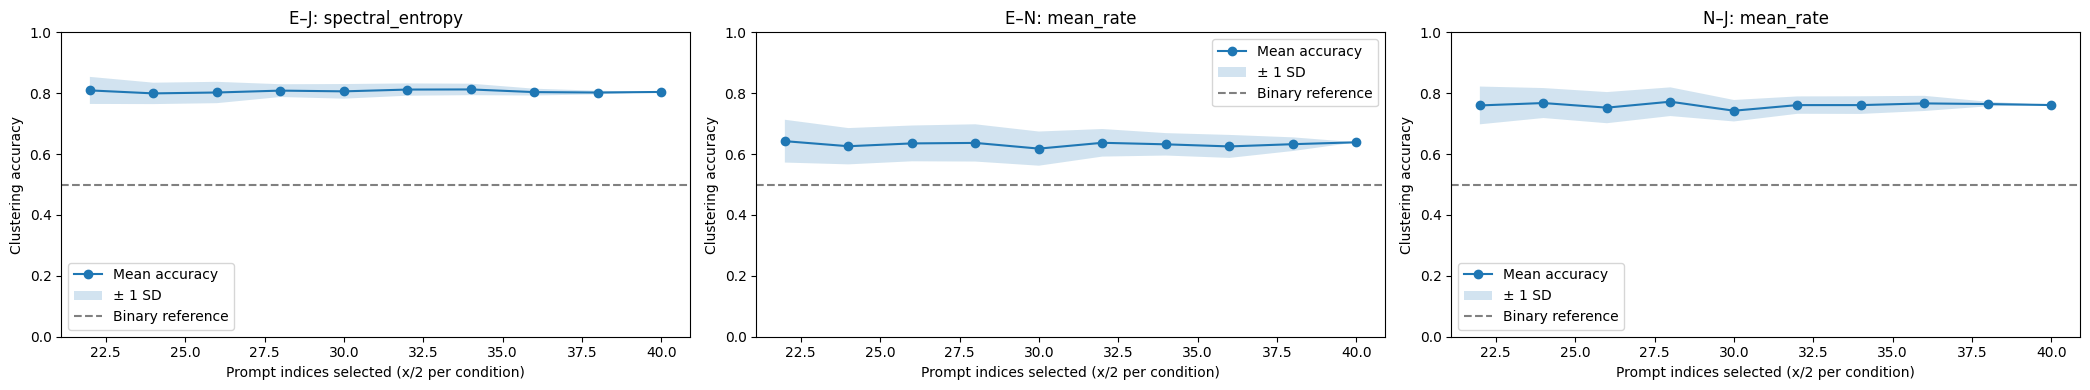

In [6]:
sweep_rows = []
for left, right in PAIRS:
    pair = f'{CODES[left]}–{CODES[right]}'
    feature = stats.loc[stats.pair == pair].sort_values('accuracy', ascending=False).iloc[0].feature
    pools = {c: df_all.loc[df_all.condition == c, 'prompt_index'].unique() for c in [left, right]}
    rng = np.random.default_rng(SEED)
    for x in SUBSET_SIZES:
        if x//2 > min(map(len, pools.values())):
            continue
        for repeat in range(N_REPEATS):
            mask = pd.Series(False, index=df_all.index)
            for cond, pool in pools.items():
                selected = rng.choice(pool, x//2, replace=False)
                mask |= (df_all.condition == cond) & df_all.prompt_index.isin(selected)
            sub = df_all.loc[mask, ['condition', feature]].dropna()
            acc, ari = kmeans_acc_ari(sub[[feature]], (sub.condition == left).astype(int))
            sweep_rows.append(dict(pair=pair, feature=feature, x=x, repeat=repeat, total=len(sub), accuracy=acc, ari=ari))
sweep_results = pd.DataFrame(sweep_rows)
sweep_summary = sweep_results.groupby(['pair', 'feature', 'x']).agg(
    mean_acc=('accuracy', 'mean'), std_acc=('accuracy', 'std'), mean_ari=('ari', 'mean'), total=('total', 'mean')).reset_index()
print(sweep_summary.to_string(index=False))
fig, axes = plt.subplots(1, len(PAIRS), figsize=(7*len(PAIRS), 4), squeeze=False)
for ax, (pair, group) in zip(axes[0], sweep_summary.groupby('pair')):
    x, mean, sd = group.x.to_numpy(), group.mean_acc.to_numpy(), group.std_acc.to_numpy()
    ax.plot(x, mean, marker='o', label='Mean accuracy')
    ax.fill_between(x, mean-sd, mean+sd, alpha=0.2, label='± 1 SD')
    ax.axhline(0.5, color='gray', ls='--', label='Binary reference')
    ax.set_title(f'{pair}: {group.feature.iloc[0].split("__")[-1]}')
    ax.set_xlabel('Prompt indices selected (x/2 per condition)')
    ax.set_ylabel('Clustering accuracy')
    ax.set_ylim(0, 1)
    ax.legend()
plt.tight_layout()
plt.show()

## 6 — Summary

In [7]:
print('Full-trace per-prompt analysis:')
print(df_all.groupby('condition').agg(traces=('run_label', 'nunique'), prompts=('prompt_index', 'size')))
print('Pairwise results: clustering on prompts, tests on trace means')
print(stats[['pair', 'feature', 'accuracy', 'ari', 'cohens_d', 't_p_corr', 'mwu_p_corr']].to_string(index=False))
if label_issues:
    print(f'Review {len(label_issues)} filename/condition mismatches before interpreting results.')

Full-trace per-prompt analysis:
           traces  prompts
condition                 
emotional      20      400
joyful         16      320
neutral        20      400
Pairwise results: clustering on prompts, tests on trace means
pair                               feature  accuracy       ari  cohens_d     t_p_corr  mwu_p_corr
 E–N        core_power.throttle__mean_rate  0.638750  0.075899  1.051946 2.581129e-02    0.021389
 E–N         core_power.throttle__variance  0.536250  0.004288  0.115343 1.000000e+00    1.000000
 E–N core_power.throttle__spectral_entropy  0.540000  0.005783  0.491888 1.000000e+00    1.000000
 E–N            core_power.throttle__slope  0.566250  0.016325  0.505733 1.000000e+00    1.000000
 E–J        core_power.throttle__mean_rate  0.594444  0.030659  1.252173 7.253479e-03    0.022912
 E–J         core_power.throttle__variance  0.550000  0.004918  0.334007 1.000000e+00    0.806005
 E–J core_power.throttle__spectral_entropy  0.804167  0.368657  2.652959 5.360618e-07